In [ ]:
# !curl https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc -o data/sst.mnmean.nc
# !curl https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/lsmask.nc -o data/lsmask.nc

In [11]:

#import xarray as xr
ds=xr.open_dataset("data/sst.mnmean.nc")
print(ds)

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2071, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-07-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
 

In [6]:
# To find the normal for each month
clim=ds["sst"].sel(time=slice("1991-01-01","2020-12-31")).groupby("time.month").mean("time")
#ds["sst"]data only pulls out the sst data  not anything else.
#sel(time=slice("1991-01-01","2020-12-31")) will keep the time slice for 30 years
#groupby will bins every timsestep by its calender month
#keep the mean of each group(12 months) for 30 years
print(clim)

<xarray.DataArray 'sst' (month: 12, lat: 89, lon: 180)> Size: 769kB
array([[[-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
...
        [       nan,        nan,        nan, ...,

In [7]:
#subtract the climatology from every month to get the anomaly, we need to subtract the climatology of its calender month for each timestamp
anom=ds["sst"].groupby("time.month")-clim
print(anom)

<xarray.DataArray 'sst' (time: 2071, lat: 89, lon: 180)> Size: 133MB
array([[[-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.76

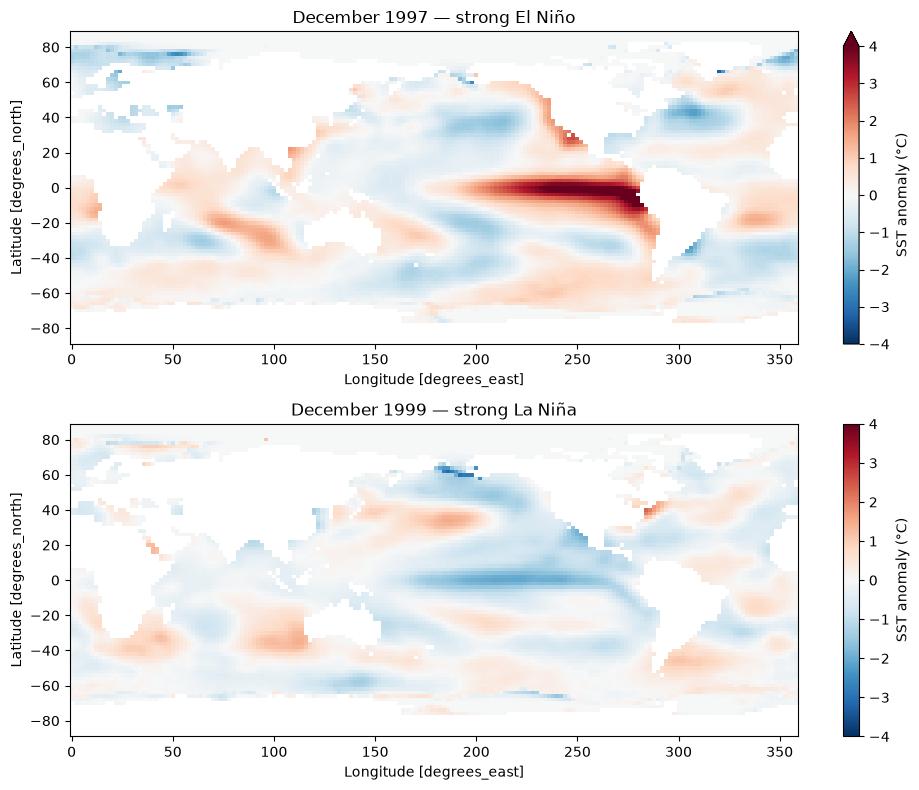

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

anom.sel(time="1997-12-01", method="nearest").plot(
    ax=axes[0], vmin=-4, vmax=4, cmap="RdBu_r", cbar_kwargs={"label": "SST anomaly (°C)"}
)
axes[0].set_title("December 1997 — strong El Niño")

anom.sel(time="1999-12-01", method="nearest").plot(
    ax=axes[1], vmin=-4, vmax=4, cmap="RdBu_r", cbar_kwargs={"label": "SST anomaly (°C)"}
)
axes[1].set_title("December 1999 — strong La Niña")

plt.tight_layout()
plt.show()

In [14]:
#download and parse the ONI
import urllib.request, os
os.makedirs("data",exist_ok=True)
urllib.request.urlretrieve("https://psl.noaa.gov/data/correlation/oni.data",
    "data/oni.data"
)
print("download oni.data")

download oni.data


In [15]:
#check
with open("data/oni.data") as f:
    lines=f.readlines()
for i, line in enumerate(lines[:5]):
    print(i,repr(line))
print("....")
for i, line in enumerate(lines[:5]):
    print(repr(line))

0 ' 1950         2026\n'
1 ' 1950  -1.53  -1.34  -1.16  -1.18  -1.07  -0.85  -0.54  -0.42  -0.39  -0.44  -0.60  -0.80\n'
2 ' 1951  -0.82  -0.54  -0.17   0.18   0.36   0.58   0.70   0.89   0.99   1.15   1.04   0.81\n'
3 ' 1952   0.53   0.37   0.34   0.29   0.20   0.00  -0.08   0.00   0.15   0.10   0.04   0.15\n'
4 ' 1953   0.40   0.60   0.63   0.66   0.75   0.77   0.75   0.73   0.78   0.84   0.84   0.81\n'
....
' 1950         2026\n'
' 1950  -1.53  -1.34  -1.16  -1.18  -1.07  -0.85  -0.54  -0.42  -0.39  -0.44  -0.60  -0.80\n'
' 1951  -0.82  -0.54  -0.17   0.18   0.36   0.58   0.70   0.89   0.99   1.15   1.04   0.81\n'
' 1952   0.53   0.37   0.34   0.29   0.20   0.00  -0.08   0.00   0.15   0.10   0.04   0.15\n'
' 1953   0.40   0.60   0.63   0.66   0.75   0.77   0.75   0.73   0.78   0.84   0.84   0.81\n'


In [19]:
#parse ONI into a tidy month series
import pandas as pd
import numpy as np

years = []
month_values = []   # list of 12-element lists

with open("data/oni.data") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 13 and parts[0].isdigit() and len(parts[0]) == 4:
            years.append(int(parts[0]))
            month_values.append([float(v) for v in parts[1:]])  # 12 values

# Build a proper monthly date range from Jan of first year to Dec of last year
start = pd.Timestamp(year=years[0], month=1, day=1)
periods = len(years) * 12
dates = pd.date_range(start=start, periods=periods, freq="MS")  # MS = month start

# Flatten the 12-per-year grid into one long list, in order
flat_values = np.array(month_values).flatten()

oni = pd.Series(data=flat_values, index=dates, name="oni")
oni = oni.where(oni > -90)   # -99.9 flag -> NaN

print("LENGTH:", len(oni))
print("MONTHS:", sorted(set(oni.index.month)))
print(oni.loc["1950"])       # should show all 12 months of 1950

LENGTH: 924
MONTHS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
1950-01-01   -1.53
1950-02-01   -1.34
1950-03-01   -1.16
1950-04-01   -1.18
1950-05-01   -1.07
1950-06-01   -0.85
1950-07-01   -0.54
1950-08-01   -0.42
1950-09-01   -0.39
1950-10-01   -0.44
1950-11-01   -0.60
1950-12-01   -0.80
Freq: MS, Name: oni, dtype: float64
